Bleu socre on coco dataset.

In [ ]:
!pip install git+https://github.com/huggingface/transformers.git@main

In [ ]:
!pip install -q datasets

**Importing** **Model**

In [ ]:
from transformers import AutoProcessor, BlipForConditionalGeneration, AutoTokenizer,AutoModelForSeq2SeqLM
# device = torch.device('cpu')
processor= AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
tokenizer = AutoTokenizer.from_pretrained("Salesforce/blip-image-captioning-base")
# AutoModelForSeq2SeqLM
model_base= BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model_target = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large")
model_tuned = model = BlipForConditionalGeneration.from_pretrained("prasanna2003/blip-image-captioning")

**Importing Dataset**

In [ ]:
from datasets import load_dataset

ds_name = "coco"  # change the dataset name here
dataset = load_dataset("MMInstruction/M3IT", ds_name)
# train_set = dataset["train"]
# validation_set = dataset["validation"]
test_set = dataset["test"]

In [ ]:
len(test_set)

## **Trying to set validation set**

**Function for changing to** **dict** **(This is not for MS Coco)**

In [ ]:

import datasets
from io import BytesIO
from base64 import b64decode
from io import BytesIO  # Import for base64 decoding
from PIL import Image
from typing import Dict, List, Any

# Assuming you have the validation_set (datasets.arrow_dataset.Dataset) object

def convert_validation_to_dict(validation_set: datasets.arrow_dataset.Dataset) -> List[Dict[str, Any]]:
    """
    Converts an ArrowDataset with potential image and text columns
    into a dictionary with "image" (decoded images) and "text" lists.

    Args:
        validation_set: The ArrowDataset object representing the validation set structure.

    Returns:
        A dictionary containing lists of decoded images and text data from the validation set.

    Raises:
        ValueError: If required columns ("image_base64_str" or "image", "text" or "instruction") are not found.
        AttributeError: If Dataset object doesn't support accessing column names.
    """
    if not validation_set:
        raise ValueError("Empty validation set provided.")

    data = []
    image_cnt = 0;
    for i in range(len(validation_set)):

        if image_cnt > 20:
          break
        else:
          image_cnt = image_cnt + 1

        print("Image No: ", image_cnt)

        # Converting base64 image to original image.
        lagbe = validation_set['image_base64_str'][i]
        image = Image.open(BytesIO(b64decode(lagbe[0])))

        # Get text data (assuming either "text" or "instruction" column)
        text = (validation_set['outputs'][i])

        data_item = {
            'image': image,
            'text': text
        }
        data.append(data_item)

    return data


# **Function for changing to dict not image hash value**

In [ ]:

import datasets
from io import BytesIO
from base64 import b64decode
from io import BytesIO  # Import for base64 decoding
from PIL import Image
from typing import Dict, List, Any


# Assuming you have the validation_set (datasets.arrow_dataset.Dataset) object

def convert_validation_to_dict_by_str(validation_set: datasets.arrow_dataset.Dataset) -> List[Dict[str, Any]]:
    """
    Converts an ArrowDataset with potential image and text columns
    into a dictionary with "image" (decoded images) and "text" lists.

    Args:
        validation_set: The ArrowDataset object representing the validation set structure.

    Returns:
        A dictionary containing lists of decoded images and text data from the validation set.

    Raises:
        ValueError: If required columns ("image_base64_str" or "image", "text" or "instruction") are not found.
        AttributeError: If Dataset object doesn't support accessing column names.
    """
    if not validation_set:
        raise ValueError("Empty validation set provided.")

    data = []
    image_cnt = 0;
    for i in range(len(validation_set)):

        if image_cnt > 200:   # Set your image count here.-----------------------
          break
        else:
          image_cnt = image_cnt + 1

        print("Image No: ", image_cnt)

        # Converting base64 image to original image.
        lagbe = validation_set['image_base64_str'][i]
        # image = Image.open(BytesIO(b64decode(lagbe[0])))
        image = lagbe[0]

        # Get text data (assuming either "text" or "instruction" column)
        text = (validation_set['outputs'][i])

        data_item = {
            'image': image,
            'text': text
        }
        data.append(data_item)

    return data


In [ ]:
test_dict = convert_validation_to_dict_by_str(test_set)

# **For Personal Image**

In [ ]:
from google.colab import files

# Upload an image file
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Read the uploaded image file
import io
from PIL import Image

image = Image.open(io.BytesIO(uploaded[file_name]))

# Display the uploaded image
image

Saving Ronaldo.jpeg to Ronaldo.jpeg


**Method for Generate Function**

In [ ]:
def Caption(model, processor, image):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    inputs = processor(images=image,return_tensors="pt").to(device)
    generated_ids = model.generate(pixel_values=inputs.pixel_values, max_length=50)
    generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return generated_caption

In [ ]:
print(f"Caption For base_model: { Caption(model_base, processor, image) }" )
print(f"Caption For tuned_model: { Caption(model, processor, image)} " )
print(f"Caption For target_model: { Caption(model_target, processor, image) } " )

**Formating the test dataset for calculating Bleu score**

In [ ]:
from collections import defaultdict  # Use defaultdict for efficient text list creation

def process_and_get_image(data_dict):
  """
  This function processes a dictionary with image and text keys. It ensures unique images
  (stored efficiently) and combines text descriptions for duplicate images, returning both
  processed data and the requested image data.

  Args:
      data_dict: The input dictionary with image and text keys.

  Returns:
      A tuple containing:
          1. Processed dictionary with unique images (stored efficiently) and combined text descriptions.
          2. Function to retrieve the actual image data for a given image hash.
  """
  seen_images = set()

  hehe = []
  processed_dict = {}
  for item in data_dict:
    image_data = item['image']
    text = item['text']
    # image_hash = hash(image_data)  # Unique identifier for image (consider a more robust hashing method)
    if image_data not in seen_images:
      seen_images.add(image_data)
      processed_dict[image_data] = [text]
    else :
      if image_data in processed_dict:
        value = processed_dict[image_data]
        value.append(text)
        processed_dict[image_data] = value

  for key, value in processed_dict.items():
    lagbe = key
    text = value
    image = Image.open(BytesIO(b64decode(lagbe)))

    data_item = {
            'image': image,
            'text': text
    }
    hehe.append(data_item)

  return hehe


In [ ]:
test_dict = process_and_get_image(test_set)
# test_dict = base64_to_image(test_dict)

## **Claculating Bleu Score**

In [ ]:
!pip install evaluate
import evaluate, torch
bleu = evaluate.load('bleu')

**Method for treaming the sentence.(only for this model)**

In [ ]:
# def clean_sentence(text):
#   """
#   This function removes the prefix "output :" and the suffix "< | eos | >" from the text.

#   Args:
#       text: The input string.

#   Returns:
#       The cleaned string, or the original text if cleaning fails.
#   """
#   if "output :" in text:
#       cleaned_text = text.split("output : ")[1]
#       if " < | eos | >" in cleaned_text:
#           cleaned_text = cleaned_text.split(" < | eos | >")[0]
#       return cleaned_text
#   else:
#       return text


def clean_sentence(text):
    """
    This function removes the prefix "output :" and the suffix "< | eos | >" from the text.
    It also cuts the sentence after the first occurrence of a period ('.').

    Args:
        text: The input string.

    Returns:
        The cleaned string, or the original text if cleaning fails.
    """
    if "output :" in text:
        cleaned_text = text.split("output : ")[1]
        if " < | eos | >" in cleaned_text:
            cleaned_text = cleaned_text.split(" < | eos | >")[0]

        # Cut the sentence after the first period
        cleaned_text = cleaned_text.split('.')[0]
        cleaned_text += '.'
        return cleaned_text.strip()  # Strip any leading/trailing whitespace
    else:
        return text


In [ ]:
len(test_dict)

Overall BLEU Score: 0.467


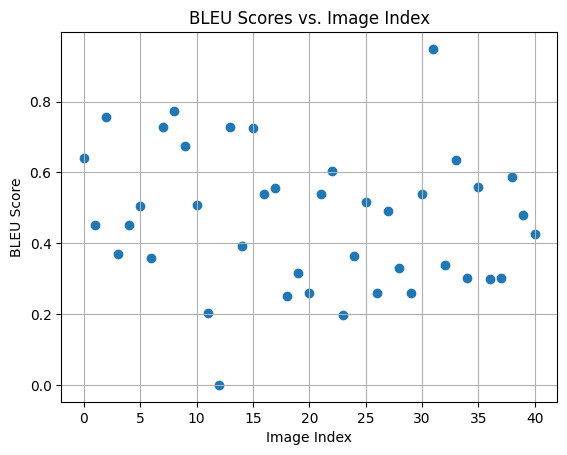

In [ ]:
# ----------------------------Calculate the real Bleu score--------------------------------------
import matplotlib.pyplot as plt
image_bleu_scores = []
image_cnt = 1
for id in test_dict:

  # print ("Image No: ", image_cnt)
  image = id['image']
  text = id['text']
  caption = Caption(model_target, processor, image)
  caption = clean_sentence(caption)

  references, predictions = [], []
  references.append(text)
  predictions.append(caption)

  results = bleu.compute(predictions=predictions, references=references, max_order = 2)

  # if results['bleu'] > 0.7:
  #   print("Reference Text: ", text)
  #   print("Predicted Text: ", caption)

  image_bleu_scores.append(results['bleu'])
  image_cnt = image_cnt + 1

final_bleu_score = sum(image_bleu_scores) / len(image_bleu_scores)
print("Overall BLEU Score: %.3f" % final_bleu_score)


# ---------------Code for scatter plot------------------ #
bleu_scores = list(image_bleu_scores)  # Extract all BLEU scores as a list
plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

# Customization (optional)
plt.xlabel("Image Index")
plt.ylabel("BLEU Score")
plt.title("BLEU Scores vs. Image Index")
plt.grid(True)

# Display the plot
plt.show()

# **Code for proxy Tuning**

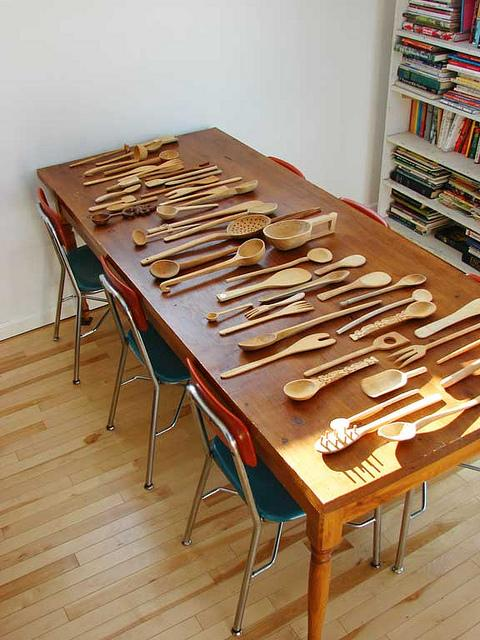

In [ ]:
image = test_dict[5]['image']
image

In [ ]:
# image = test_dict[5]['image']
inputs = processor(images=image, return_tensors="pt").to(device)

decoder_input_ids = [model_base.decoder_input_ids]
input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

model_base.to(device)
model_tuned.to(device)
model_target.to(device)

predicted_ids = []

with torch.no_grad():
    for i in range(30):

        # input_ids_tuned.input_ids = inputs.input_ids
        # input_ids_target.input_ids = inputs.input_ids

        logits_base = model_base(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
        logits_tuned = model_tuned(pixel_values = inputs.pixel_values, input_ids = input_ids).logits[:,i,:]
        logits_target = model_target(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
        logits = (
            logits_target + (logits_tuned - logits_base)
        )
        predicted_id = logits.argmax(-1)
        predicted_ids.append(predicted_id.item())
        # add predicted id to decoder_input_ids
        input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
        if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
          break


In [ ]:
def calculate_bleu_score(predicted_sentences, reference_sentences):
    reference, prediction = [], []
    reference.append(reference_sentences)
    prediction.append(predicted_sentences)

    lagbe = bleu.compute(predictions=prediction, references=reference, max_order = 2)
    return lagbe


Overall BLEU Score: 0.050


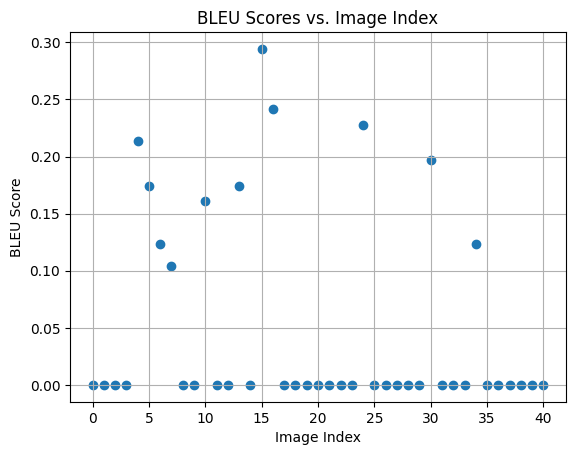

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_base.to(device)
model_tuned.to(device)
model_target.to(device)

total_bleu_score = []

for id in test_dict:
    iamge = id['image']
    text = id['text']

    inputs = processor(images=image, return_tensors="pt").to(device)
    decoder_input_ids = [model_base.decoder_input_ids]
    input_ids = decoder_input_ids = torch.tensor([decoder_input_ids]).to(device)

    predicted_ids = []

    with torch.no_grad():
      for i in range(30):

          logits_base = model_base(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits_tuned = model_tuned(pixel_values = inputs.pixel_values, input_ids = input_ids).logits[:,i,:]
          logits_target = model_target(pixel_values = inputs.pixel_values, input_ids =input_ids).logits[:,i,:]
          logits = (
              logits_target + (logits_tuned - logits_base)
          )
          predicted_id = logits.argmax(-1)
          predicted_ids.append(predicted_id.item())
          # add predicted id to decoder_input_ids
          input_ids = torch.cat([input_ids, predicted_id.unsqueeze(0)], dim=1)
          if(tokenizer.decode([predicted_id.squeeze()]) == "[SEP]"):
            break

    predicted_text = tokenizer.decode(predicted_ids,skip_special_tokens = True)
    predicted_text = clean_sentence(predicted_text)

    bleu_score = calculate_bleu_score (predicted_text, text)
    total_bleu_score.append(bleu_score['bleu'])

final_bleu_score = sum(total_bleu_score) / len(total_bleu_score)
print("Overall BLEU Score: %.3f" % final_bleu_score)


# ---------------Code for scatter plot------------------ #
bleu_scores = list(total_bleu_score)  # Extract all BLEU scores as a list
plt.scatter(range(len(bleu_scores)), bleu_scores)  # Use range(len()) for x-axis

# Customization (optional)
plt.xlabel("Image Index")
plt.ylabel("BLEU Score")
plt.title("BLEU Scores vs. Image Index")
plt.grid(True)

# Display the plot
plt.show()



In [ ]:
sentence = tokenizer.decode(predicted_ids,skip_special_tokens = True)
sentence = clean_sentence(sentence)
sentence

'a blue and white motorcycle is parked on a tile floor.'

In [ ]:
image = test_dict[5]['text']
image

['Multiple wooden spoons are shown on a table top.',
 'A table surrounded by chairs and filled with cooking utensils.',
 'Wooden spoons laid out across a kitchen table.',
 'Wooden spoons and forks are all over a table.',
 'A table and chairs with wooden kitchen tools on top.']

In [ ]:

image
sentence = Caption (model_target, processor, image)
print (sentence)
sentence = Caption (model_base, processor, image)
print (sentence)
sentence = Caption (model_tuned, processor, image)
print (sentence)

there is a motorcycle that is sitting on a shelf in a room
a motorcycle is parked in a wine cellar
output : a motorcycle with the word cafe on the front < | eos | >


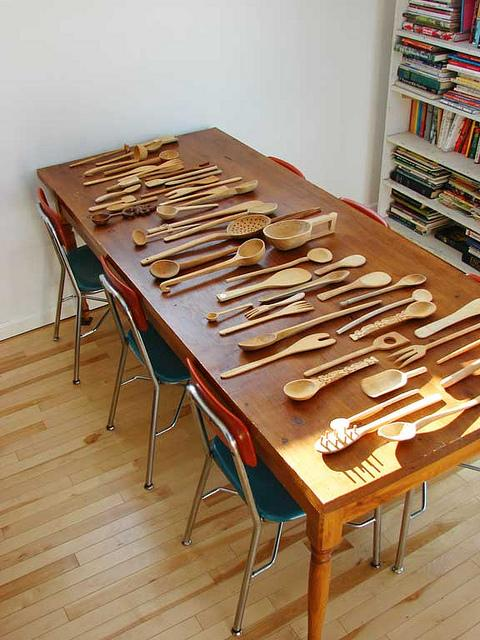

In [ ]:
image = test_dict[5]['image']
image

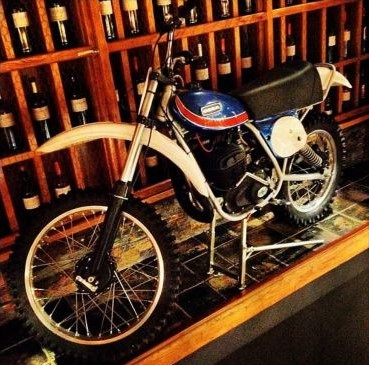

In [ ]:
iamge = test_dict[3]['image']
image